# Feature Engineering Methods

# Create Features

In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

In [3]:
df

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0


In [5]:
# Lag features (per store and item)
df['lag_1'] = df['unit_sales'].shift(1)
df['lag_7'] = df['unit_sales'].shift(7)
df['lag_30'] = df['unit_sales'].shift(30)

In [6]:
df

,date,unit_sales,lag_1,lag_7,lag_30
0,2013-01-02,582.0,NaN,NaN,NaN
1,2013-01-03,310.0,582.0,NaN,NaN
2,2013-01-04,338.0,310.0,NaN,NaN
3,2013-01-05,654.0,338.0,NaN,NaN
4,2013-01-06,979.0,654.0,NaN,NaN
...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0
450,2014-03-28,523.0,328.0,456.0,388.0
451,2014-03-29,647.0,523.0,567.0,587.0
452,2014-03-30,599.0,647.0,603.0,346.0


In [10]:
(582+310)/2

446.0

In [8]:
df["unit_sales"]

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
449    328.0
450    523.0
451    647.0
452    599.0
453    415.0
Name: unit_sales, Length: 454, dtype: float64

In [11]:
df["unit_sales"].rolling(window=2).mean().shift(1)

0        NaN
1        NaN
2      446.0
3      324.0
4      496.0
       ...  
449    412.0
450    380.0
451    425.5
452    585.0
453    623.0
Name: unit_sales, Length: 454, dtype: float64

In [12]:
# Rolling statistics
df['rollings_avg_2'] = df["unit_sales"].rolling(window=2).mean().shift(1)


In [13]:
df

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2
0,2013-01-02,582.0,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,582.0,NaN,NaN,NaN
2,2013-01-04,338.0,310.0,NaN,NaN,446.0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0
4,2013-01-06,979.0,654.0,NaN,NaN,496.0
...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0
450,2014-03-28,523.0,328.0,456.0,388.0,380.0
451,2014-03-29,647.0,523.0,567.0,587.0,425.5
452,2014-03-30,599.0,647.0,603.0,346.0,585.0


In [16]:
df['date'].dt.dayofweek

0      2
1      3
2      4
3      5
4      6
      ..
449    3
450    4
451    5
452    6
453    0
Name: date, Length: 454, dtype: int32

In [17]:
'''Monday = 0

Tuesday = 1

Wednesday = 2

Thursday = 3

Friday = 4

Saturday = 5

Sunday = 6'''

df['day_of_week'] = df['date'].dt.dayofweek


In [18]:
df

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6
...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0,3
450,2014-03-28,523.0,328.0,456.0,388.0,380.0,4
451,2014-03-29,647.0,523.0,567.0,587.0,425.5,5
452,2014-03-30,599.0,647.0,603.0,346.0,585.0,6


In [30]:
def is_weekend(x):
    if x >= 5:
        return 1
    else:
        return 0


df['is_weekend'] = df['day_of_week'].apply(is_weekend)

#df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [31]:
df

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0,3,0
450,2014-03-28,523.0,328.0,456.0,388.0,380.0,4,0
451,2014-03-29,647.0,523.0,567.0,587.0,425.5,5,1
452,2014-03-30,599.0,647.0,603.0,346.0,585.0,6,1


In [33]:
#df.to_csv("data/feature_engineered_timeseries.csv", index=False)

# ML Part

In [34]:
split_date = '2014-01-01'
train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

In [36]:
test

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
364,2014-01-01,436.0,436.0,365.0,421.0,515.5,2,0
365,2014-01-02,589.0,436.0,418.0,493.0,436.0,3,0
366,2014-01-03,474.0,589.0,419.0,454.0,512.5,4,0
367,2014-01-04,767.0,474.0,499.0,265.0,531.5,5,1
368,2014-01-05,1203.0,767.0,552.0,388.0,620.5,6,1
...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,412.0,3,0
450,2014-03-28,523.0,328.0,456.0,388.0,380.0,4,0
451,2014-03-29,647.0,523.0,567.0,587.0,425.5,5,1
452,2014-03-30,599.0,647.0,603.0,346.0,585.0,6,1


In [37]:
# Define target variable (unit_sales) and features
X_train = train.drop('unit_sales', axis=1)
X_train = X_train.drop('date', axis=1)
y_train = train['unit_sales']

X_test = test.drop('unit_sales', axis=1)
X_test = X_test.drop('date', axis=1)
y_test = test['unit_sales']

In [38]:
X_train

,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,NaN,NaN,NaN,NaN,2,0
1,582.0,NaN,NaN,NaN,3,0
2,310.0,NaN,NaN,446.0,4,0
3,338.0,NaN,NaN,324.0,5,1
4,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...
359,418.0,441.0,474.0,391.5,4,0
360,419.0,630.0,258.0,418.5,5,1
361,499.0,985.0,363.0,459.0,6,1
362,552.0,523.0,726.0,525.5,0,0


In [39]:
y_train

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
359    419.0
360    499.0
361    552.0
362    595.0
363    436.0
Name: unit_sales, Length: 364, dtype: float64

## XGBoost Model

In [40]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    enable_categorical=True
)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)



,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
train

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
359,2013-12-27,419.0,418.0,441.0,474.0,391.5,4,0
360,2013-12-28,499.0,419.0,630.0,258.0,418.5,5,1
361,2013-12-29,552.0,499.0,985.0,363.0,459.0,6,1
362,2013-12-30,595.0,552.0,523.0,726.0,525.5,0,0


In [43]:
# Schummeln!!
y_pred = xgboost_model.predict(X_test)

In [52]:
xgboost_model.predict(pd.DataFrame({"lag_1":[440], "lag_7": [332], "lag_30": [290], "rollings_avg_2": [470], "day_of_week":[1], "is_weekend":[0]}))[0]

np.float32(418.7757)

In [20]:
# Example
xgboost_model.predict(pd.DataFrame({"lag_1":[440], "lag_7": [332], "lag_30": [290], "rollings_avg_2": [470], "day_of_week":[1], "is_weekend":[0]}))[0]

np.float32(404.5666)

In [54]:
train.set_index("date")

,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
date,,,,,,,
2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...
2013-12-27,419.0,418.0,441.0,474.0,391.5,4,0
2013-12-28,499.0,419.0,630.0,258.0,418.5,5,1
2013-12-29,552.0,499.0,985.0,363.0,459.0,6,1


In [58]:
last_date + pd.Timedelta(days=10)

Timestamp('2014-01-10 00:00:00')

In [55]:
train_df = train.set_index("date")
history = train_df["unit_sales"].copy()
forecasts = []
last_date = history.index[-1]
next_date = last_date + pd.Timedelta(days=1)
next_date

Timestamp('2014-01-01 00:00:00')

In [61]:

def iterative_forecast(model, train_df, n_future_days):
    train_df = train_df.set_index("date")
    # Work on a copy so we don't mutate the original
    history = train_df["unit_sales"].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)


        # CHANGE HERE!!!!
        # --- Lag features ---
        lag_1  = history.iloc[-1]
        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]
        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]

        # --- Rolling average (last 2 values) ---
        rolling_avg_2 = history.iloc[-2:].mean()

        # --- Calendar features ---
        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday
        is_weekend  = int(day_of_week >= 5)

        # --- Build the feature row (column order must match training) ---
        row = pd.DataFrame({
            "lag_1":          [lag_1],
            "lag_7":          [lag_7],
            "lag_30":         [lag_30],
            "rollings_avg_2": [rolling_avg_2],
            "day_of_week":    [day_of_week],
            "is_weekend":     [is_weekend],
        })


        # UNITL HERE CHANGE!!!

        # --- Predict and store ---
        yhat = model.predict(row)[0]
        forecasts.append({"date": next_date, "unit_sales": yhat})

        # --- Append prediction to history so next iteration can use it ---
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

In [60]:
train

,date,unit_sales,lag_1,lag_7,lag_30,rollings_avg_2,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,446.0,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,324.0,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,496.0,6,1
...,...,...,...,...,...,...,...,...
359,2013-12-27,419.0,418.0,441.0,474.0,391.5,4,0
360,2013-12-28,499.0,419.0,630.0,258.0,418.5,5,1
361,2013-12-29,552.0,499.0,985.0,363.0,459.0,6,1
362,2013-12-30,595.0,552.0,523.0,726.0,525.5,0,0


In [62]:
forecast = iterative_forecast(xgboost_model, train, len(X_test))
forecast

,date,unit_sales
0,2014-01-01,533.380493
1,2014-01-02,390.803497
2,2014-01-03,334.415771
3,2014-01-04,559.665894
4,2014-01-05,584.142395
...,...,...
85,2014-03-27,271.055695
86,2014-03-28,403.992371
87,2014-03-29,575.904419
88,2014-03-30,724.385376


In [65]:
y_pred = forecast["unit_sales"]

 MAE: 102.54579366048178, MSE: 22919.058095394415, R2: 0.31919546680561106


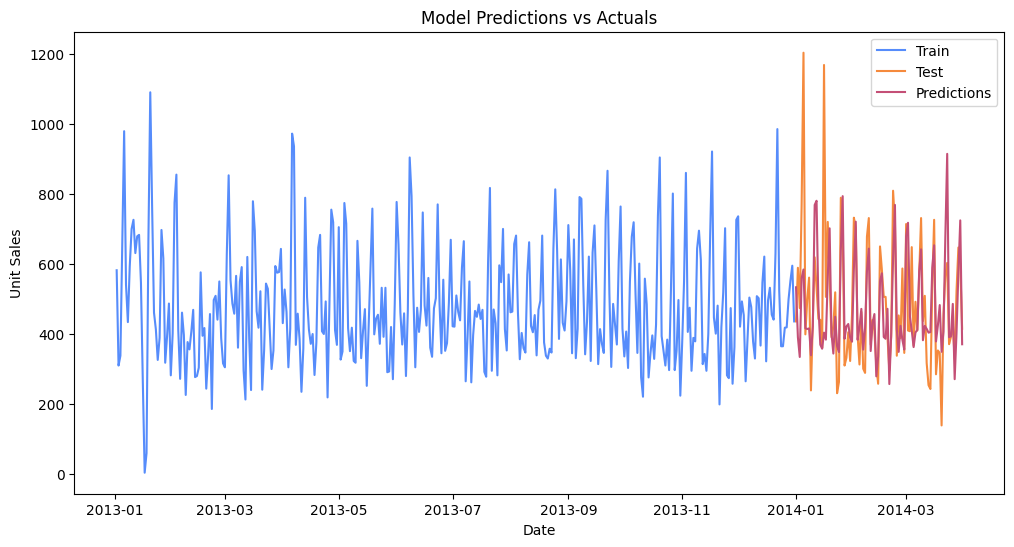

In [66]:

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


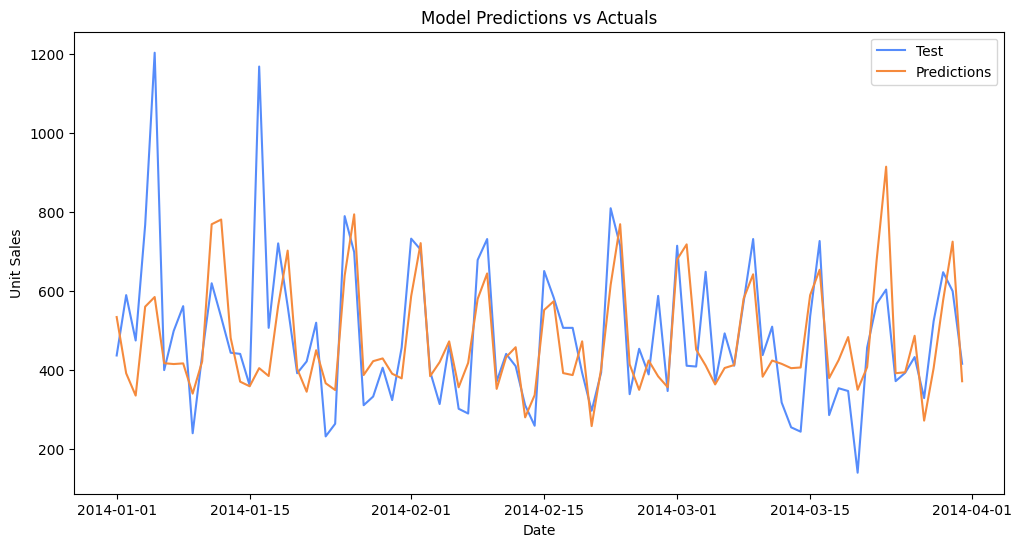

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


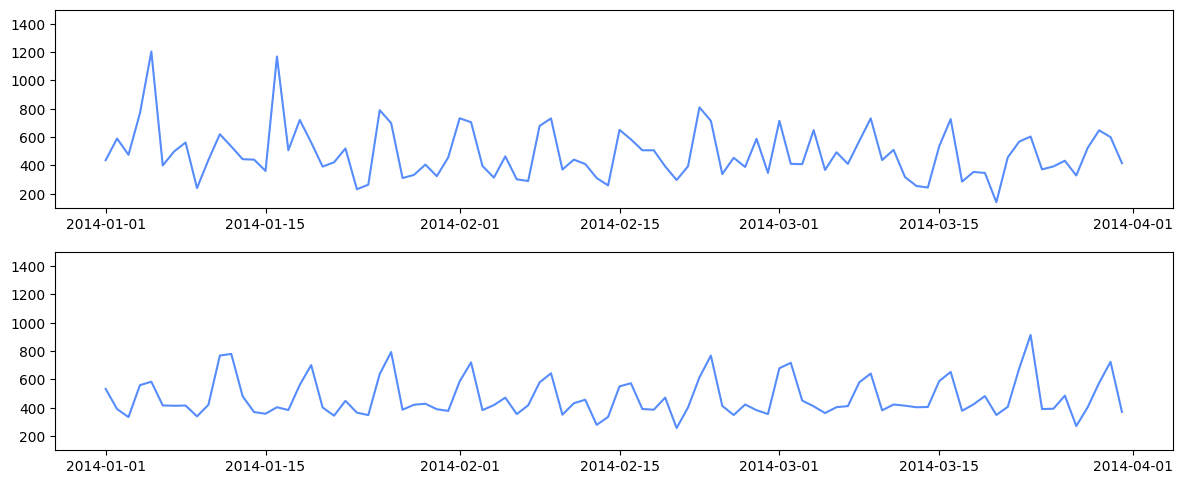

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Create 1 row, 2 columns
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# Plot on first subplot (left)
axes[0].plot(test['date'], test['unit_sales'], label='Test')
axes[0].set_ylim(100, 1500)

# Plot on second subplot (right)
axes[1].plot(test['date'], y_pred, label='Predictions')
axes[1].set_ylim(100, 1500)

plt.tight_layout()
plt.show()

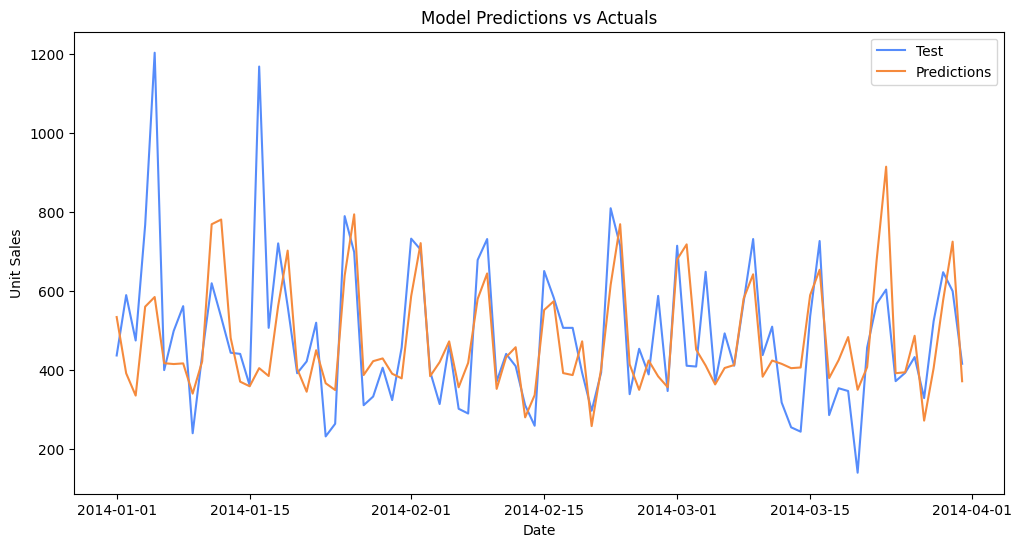

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

## Sklearn Models

In [40]:
# If you are using models that do not handle missing values, you can drop rows with NaN values in the training set
"""
X_train = X_train.dropna()
y_train = y_train[X_train.index]
"""



'\nX_train = X_train.dropna()\ny_train = y_train[X_train.index]\n'

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Initialize models
model = LinearRegression() # RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42) # You can switch to LinearRegression() or SVR() to test other models

# Train the model
model.fit(X_train, y_train)
# Make predictions
forecast = iterative_forecast(model, train, len(X_test))
y_pred = forecast["unit_sales"]


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [72]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")

 MAE: 97.50749866765523, MSE: 19681.03657462358, R2: 0.4153800360294555


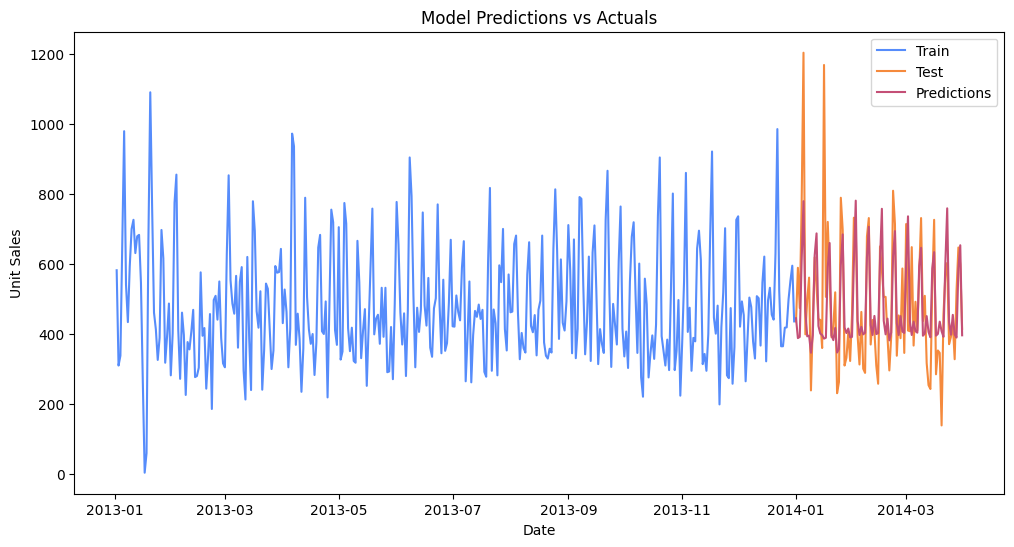

In [73]:
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()
